In [1]:
import cv2
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
img = cv2.imread("/content/drive/MyDrive/bird.jpg", 1)

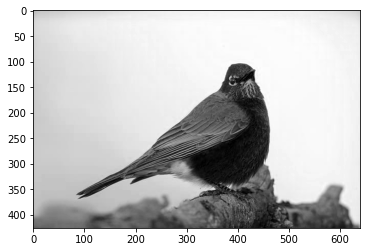

In [5]:
#########################MANUAL##################
#Separate blue channels as they contain nuclei pixels (DAPI). 
blue_channel = img[:,:,0]
plt.imshow(blue_channel, cmap='gray')

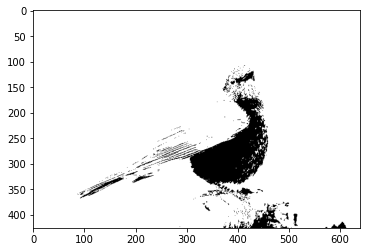

In [6]:
#plt.hist(blue_channel.flat, bins=100, range=(0,150))  #.flat returns the flattened numpy array (1D)

#Manual thresholding by setting threshold value to numpy array
#After thresholding we will get a binary image.
background = (blue_channel <= 40)
nuclei = (blue_channel > 40)
plt.imshow(nuclei, cmap='gray')

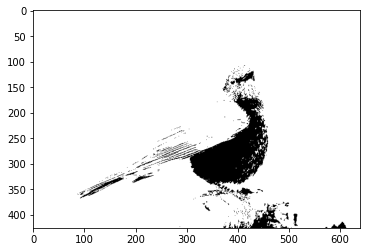

In [7]:
#Using opencv to perform manual threshold
#All pixels above 40 will have pixel value 255
#Should be exactly same as the above method. 
ret1, thresh1 = cv2.threshold(blue_channel, 40, 255, cv2.THRESH_BINARY)
plt.imshow(thresh1, cmap='gray')

In [8]:
######################################################

############# AUTO using OTSU ##########################
#Using opencv for otsu based automatic thresholding
ret2, thresh2 = cv2.threshold(blue_channel,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
#Reports a value of 50 as threshold for the nuclei.


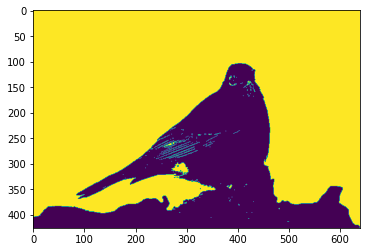

In [9]:
#Now, let us segment the image, meaning assign values of 0, 1, 2, ... to pixels
import numpy as np 
#np.digitize needs bins to be defined as an array
#So let us convert the threshold value to an array
# #np.digitize assign values 0, 1, 2, 3, ... to pixels in each class.
#For binary it wold be 0 and 1. 
regions1=np.digitize(blue_channel, bins=np.array([ret2]))
plt.imshow(regions1)